# Rayong Crop Tracker · End-to-end pipeline

Sentinel-2 L2A → OpenSR super-resolution → diffusion-sampled minority-class augmentation → texture + index features → Random Forest cascade.

Stages map 1:1 to the [tracker board](../README.md). Heavy steps cache to disk so a kernel restart only costs a few imports.

## 1 · Setup

Use `notebooks/environment.yml` (`conda env create -f notebooks/environment.yml`). If you must pip-install, uncomment the cell below.


In [ ]:
# !pip install -q --upgrade \
#     openeo "openeo-processes-dask[implementations]" pystac-client planetary-computer \
#     rasterio rioxarray xarray geopandas shapely pyproj fiona mgrs \
#     opensr-model omegaconf diffusers transformers accelerate safetensors \
#     scikit-image scikit-learn matplotlib seaborn tqdm pyarrow \
#     --extra-index-url https://download.pytorch.org/whl/cu121 "torch==2.3.1+cu121" torchvision torchaudio

In [1]:
from __future__ import annotations
import sys, json, math, warnings, datetime as dt
from pathlib import Path
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import rasterio
import rioxarray as rxr
import xarray as xr
import geopandas as gpd

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_context("notebook"); sns.set_style("whitegrid")
print("python:", sys.version.split()[0])


python: 3.12.13


In [ ]:
def _repo_root_default() -> Path:
    if "__file__" in globals():
        return Path(__file__).resolve().parents[1]
    here = Path.cwd().resolve()
    for p in (here, *here.parents):
        if (p / "package.json").exists() and (p / "notebooks").exists():
            return p
    return here


# 15-class taxonomy used by §5 (raster), §6 (synth), §7 (features), §8 (RF).
# Each entry: (display name, LDD LU_CODE prefixes mapped into the bucket).
# Anything in the shapefile that doesn't match goes to "Others". Adjust the
# code lists if your LDD layer uses different codes.
TAXONOMY: tuple[tuple[str, tuple[str, ...]], ...] = (
    ("Rice",        ("A101",)),
    ("Cassava",     ("A201",)),
    ("Pineapple",   ("A202",)),
    ("Para rubber", ("A301",)),
    ("Oil palm",    ("A302",)),
    ("Durian",      ("A401",)),
    ("Mango",       ("A402",)),
    ("Jackfruit",   ("A403",)),
    ("Coconut",     ("A303",)),
    ("Mangosteen",  ("A404",)),
    ("Longan",      ("A405",)),
    ("Rambutan",    ("A406",)),
    ("Langsat",     ("A407",)),
    ("Reservoir",   ("W201", "W101")),
    ("Others",      ()),
)
CLASS_NAMES: tuple[str, ...] = tuple(name for name, _ in TAXONOMY)
class_name_to_int: dict[str, int] = {name: i + 1 for i, name in enumerate(CLASS_NAMES)}
int_to_class_name: dict[int, str] = {v: k for k, v in class_name_to_int.items()}
OTHERS_INT: int = class_name_to_int["Others"]

_CODE_PREFIX_TO_NAME: dict[str, str] = {}
for _name, _codes in TAXONOMY:
    for _c in _codes:
        _CODE_PREFIX_TO_NAME[_c] = _name


def lu_code_to_class_name(code: str | float | None) -> str:
    """LDD LU_CODE → display name. Unknown / NaN / empty → "Others"."""
    if not isinstance(code, str) or not code:
        return "Others"
    if code in _CODE_PREFIX_TO_NAME:
        return _CODE_PREFIX_TO_NAME[code]
    # also accept the 4-char prefix in case the shapefile has 5+ char codes
    head = code[:4]
    return _CODE_PREFIX_TO_NAME.get(head, "Others")


@dataclass
class Config:
    repo_root:   Path = field(default_factory=_repo_root_default)
    work_root:   Path = None
    cache_root:  Path = None
    out_root:    Path = None
    ldd_landuse: Path = None
    ldd_admin:   Path = None

    aoi_quadrant: str   = "SE"        # FULL / NW / NE / SW / SE / CUSTOM
    aoi_bbox:     tuple = (101.55, 12.70, 101.65, 12.80)
    aoi_name:     str   = "klaeng_10km"

    time_start: str = "2024-01-01"
    time_end:   str = "2024-12-31"

    # Smoke mode shrinks the AOI + time window + RF size so the whole
    # pipeline finishes in a few minutes. Flip to False for a full run.
    smoke_test:           bool  = True
    smoke_bbox_deg:       float = 0.025          # half-side around AOI centroid (~2.5 km)
    smoke_months:         int   = 2
    smoke_rf_estimators:  int   = 200
    smoke_sr_steps:       int   = 25
    full_sr_steps:        int   = 50

    bands_10m: tuple = ("B02", "B03", "B04", "B08")
    bands_20m: tuple = ("B05", "B06", "B07", "B11", "B12")
    scl_band:  str   = "SCL"

    sr_scale: int = 4
    sr_steps: int = 50      # resolved at runtime from smoke/full

    # Minority classes by display name. Picked to bias toward orchard /
    # specialty crops that are usually sparse in the LDD layer.
    minority_classes:  tuple = ("Durian", "Langsat", "Rambutan", "Mangosteen")
    samples_per_minor: int   = 200

    rf_n_estimators: int  = 600
    rf_max_depth:    int  = None
    cascade:         bool = True
    seed:            int  = 42

    def __post_init__(self):
        data = self.repo_root / "data"
        self.work_root   = self.work_root   or data
        self.cache_root  = self.cache_root  or data / "_cache"
        self.out_root    = self.out_root    or data / "_out"
        self.ldd_landuse = self.ldd_landuse or data / "landuse_ryg"
        self.ldd_admin   = self.ldd_admin   or data / "admin_ryg"
        self.sr_steps = self.smoke_sr_steps if self.smoke_test else self.full_sr_steps
        if self.smoke_test:
            self.rf_n_estimators = self.smoke_rf_estimators


# Quadrant bboxes mirror lib/rayong.ts (split at province centroid).
_W, _S, _E, _N = 100.9845, 12.5834, 101.8305, 13.1635
_CLNG, _CLAT  = 101.4291, 12.8539
QUADRANT_BBOX = {
    "FULL": (_W, _S, _E, _N),
    "NW":   (_W,    _CLAT, _CLNG, _N),
    "NE":   (_CLNG, _CLAT, _E,    _N),
    "SW":   (_W,    _S,    _CLNG, _CLAT),
    "SE":   (_CLNG, _S,    _E,    _CLAT),
}

CFG = Config()
if CFG.aoi_quadrant != "CUSTOM":
    if CFG.aoi_quadrant not in QUADRANT_BBOX:
        raise ValueError(f"unknown aoi_quadrant '{CFG.aoi_quadrant}'")
    CFG.aoi_bbox = QUADRANT_BBOX[CFG.aoi_quadrant]
    CFG.aoi_name = f"rayong_{CFG.aoi_quadrant.lower()}"

if CFG.smoke_test:
    w, s, e, n = CFG.aoi_bbox
    cx, cy = (w + e) / 2, (s + n) / 2
    d = CFG.smoke_bbox_deg
    CFG.aoi_bbox = (cx - d, cy - d, cx + d, cy + d)
    start = pd.to_datetime(CFG.time_start)
    end_target = start + pd.DateOffset(months=CFG.smoke_months)
    if pd.to_datetime(CFG.time_end) > end_target:
        CFG.time_end = end_target.strftime("%Y-%m-%d")
    CFG.aoi_name = f"{CFG.aoi_name}_smoke"

for d in (CFG.cache_root, CFG.out_root, CFG.out_root / "figs"):
    d.mkdir(parents=True, exist_ok=True)

mode = "SMOKE TEST" if CFG.smoke_test else "FULL LOAD"
print(f"[{mode}] AOI {CFG.aoi_quadrant} · bbox {CFG.aoi_bbox} · name {CFG.aoi_name}")
print(f"          time   {CFG.time_start} → {CFG.time_end}")
print(f"          sr_steps {CFG.sr_steps} · rf_n_estimators {CFG.rf_n_estimators}")
print(f"          classes {len(CLASS_NAMES)} · minority {CFG.minority_classes}")
if CFG.smoke_test:
    print("          flip CFG.smoke_test = False in this cell to run the full load.")


In [3]:
import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"torch {torch.__version__} · {DEVICE}")
if DEVICE == "cuda":
    print(f"  gpu: {torch.cuda.get_device_name(0)} · {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")


torch 2.3.1+cu121 · cuda
  gpu: NVIDIA GeForce RTX 3080 · 10.7 GB


## 2 · Sentinel-2 L2A · monthly medians via CDSE

OIDC login on first run. Result cached as one GeoTIFF per month.


In [4]:
import openeo
CONN = openeo.connect("openeo.dataspace.copernicus.eu")
try:    CONN.authenticate_oidc()
except Exception as e: print("auth needed:", e)
print("connected:", CONN.capabilities().get("title", "CDSE openEO"))


Authenticated using refresh token.
connected: Copernicus Data Space Ecosystem openEO API


In [5]:
def s2_cache_dir(cfg: Config) -> Path:
    out = cfg.cache_root / "s2_monthly" / cfg.aoi_name
    out.mkdir(parents=True, exist_ok=True)
    return out


def fetch_s2_monthly_median(cfg: Config, force: bool = False) -> Path:
    """Cloud-masked monthly-median S2. Skips the openEO job if cache exists."""
    out = s2_cache_dir(cfg)
    cached = sorted(out.glob("*.tif"))
    if cached and not force:
        print(f"cache hit · {len(cached)} files")
        return out

    bbox = dict(west=cfg.aoi_bbox[0], south=cfg.aoi_bbox[1],
                east=cfg.aoi_bbox[2], north=cfg.aoi_bbox[3], crs="EPSG:4326")
    bands = list(cfg.bands_10m) + list(cfg.bands_20m) + [cfg.scl_band]

    cube = CONN.load_collection("SENTINEL2_L2A",
                                spatial_extent=bbox,
                                temporal_extent=[cfg.time_start, cfg.time_end],
                                bands=bands, max_cloud_cover=85)
    scl = cube.band(cfg.scl_band)
    cube = cube.mask((scl == 3) | (scl == 8) | (scl == 9) | (scl == 10))
    cube = cube.filter_bands(list(cfg.bands_10m) + list(cfg.bands_20m))
    cube = cube.resample_spatial(resolution=10, method="bilinear")
    cube = cube.aggregate_temporal_period(period="month", reducer="median")

    job = cube.execute_batch(title=f"S2 monthly · {cfg.aoi_name}", out_format="GTiff")
    job.get_results().download_files(str(out))
    return out


S2_DIR = fetch_s2_monthly_median(CFG)


cache hit · 2 files


In [6]:
def load_s2_stack(s2_dir: Path) -> xr.DataArray:
    tifs = sorted(s2_dir.glob("*.tif"))
    arrs = []
    for p in tifs:
        a = rxr.open_rasterio(p, masked=True).astype("float32")
        month = "".join(c for c in p.stem if c.isdigit())[:6]
        a = a.expand_dims(time=[pd.to_datetime(month, format="%Y%m")])
        arrs.append(a)
    stack = xr.concat(arrs, dim="time").rename({"band": "band_idx"})
    print(f"S2 stack {stack.shape} · crs {stack.rio.crs}")
    return stack


S2 = load_s2_stack(s2_cache_dir(CFG))

S2 stack (2, 9, 560, 550) · crs EPSG:32647


## 3 · OpenSR · super-resolution ×4

`opensr_model.SRLatentDiffusion` on B02/B03/B04/B08. 4× upsample, reflectance out. 20 m bands stay native and are bilinearly upsampled when needed.


In [7]:
import opensr_model
from omegaconf import OmegaConf
from io import StringIO
import requests

_SR_CFG_URL = "https://raw.githubusercontent.com/ESAOpenSR/opensr-model/refs/heads/main/opensr_model/configs/config_10m.yaml"
_SR_MODEL = _SR_CFG = None


def get_sr_model():
    global _SR_MODEL, _SR_CFG
    if _SR_MODEL is None:
        _SR_CFG = OmegaConf.load(StringIO(requests.get(_SR_CFG_URL, timeout=30).text))
        _SR_MODEL = opensr_model.SRLatentDiffusion(_SR_CFG, device=DEVICE)
        _SR_MODEL.load_pretrained(_SR_CFG.ckpt_version)
        _SR_MODEL.eval()
        print(f"opensr-model loaded · ckpt {_SR_CFG.ckpt_version}")
    return _SR_MODEL


SR · months:   0%|          | 0/2 [00:00<?, ?it/s]

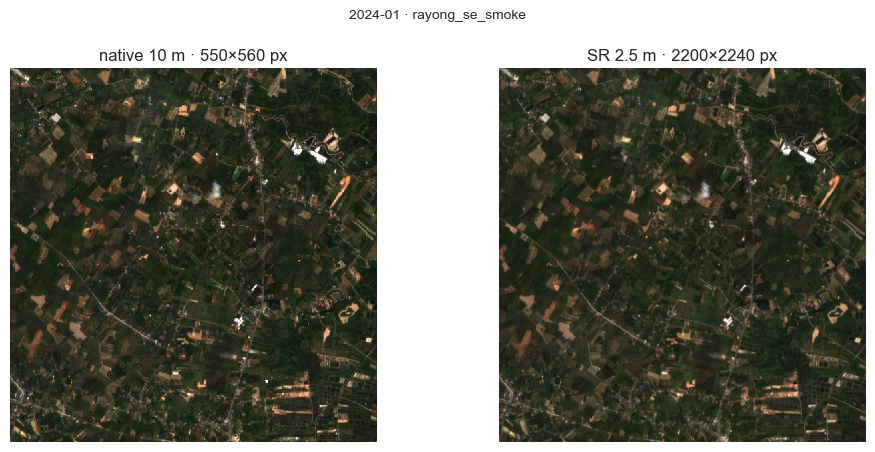

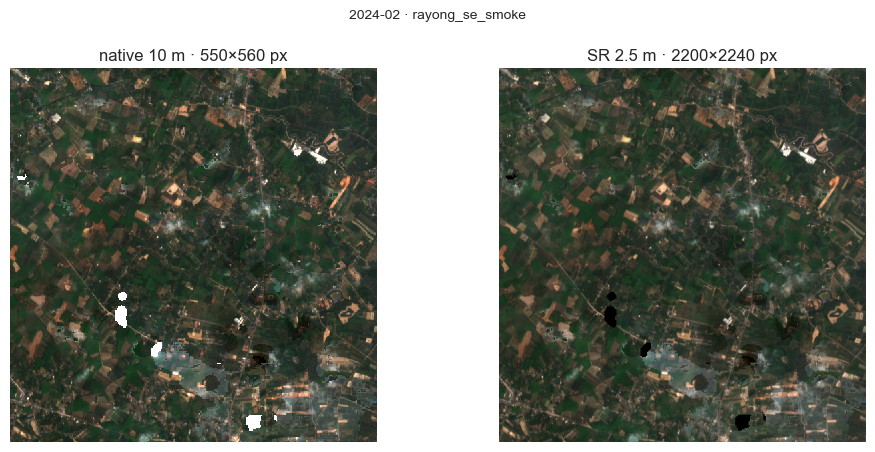

SR stack (2, 4, 2240, 2200) · res (2.5, -2.5)


In [8]:
@torch.no_grad()
def super_resolve_month(month_arr: xr.DataArray, tile: int = 128, overlap: int = 32, steps: int | None = None, desc: str = "tiles") -> xr.DataArray:
    """Tile-wise SR. Model expects (B, 4, 128, 128) and returns 4x upsampled.

    steps  : diffusion sampling count. Defaults to CFG.sr_steps (25 in smoke
             mode, 50 in full load). Pass 100 to match OpenSR's reference.
    desc   : label for the inner per-tile progress bar.
    """
    if steps is None:
        steps = CFG.sr_steps
    model = get_sr_model()
    rgb_nir = month_arr.isel(band_idx=slice(0, 4)).values.astype("float32") / 10000.0
    C, H, W = rgb_nir.shape
    out = np.zeros((C, H * CFG.sr_scale, W * CFG.sr_scale), dtype="float32")
    cnt = np.zeros_like(out[0])

    step = tile - overlap
    coords = [(y, x) for y in range(0, H, step) for x in range(0, W, step)]
    for (y, x) in tqdm(coords, desc=desc, leave=False, mininterval=1.0):
        patch = rgb_nir[:, y:y+tile, x:x+tile]
        ph, pw = patch.shape[1], patch.shape[2]
        if ph < 16 or pw < 16: continue
        if ph < tile or pw < tile:
            pad = np.zeros((C, tile, tile), dtype="float32")
            pad[:, :ph, :pw] = patch
            patch = pad
        t = torch.from_numpy(patch).unsqueeze(0).to(DEVICE)
        sr = model.forward(t, sampling_steps=steps).squeeze(0).cpu().numpy()
        sr = sr[:, : ph * CFG.sr_scale, : pw * CFG.sr_scale]
        ys, xs = y * CFG.sr_scale, x * CFG.sr_scale
        out[:, ys:ys+sr.shape[1], xs:xs+sr.shape[2]] += sr
        cnt[ys:ys+sr.shape[1], xs:xs+sr.shape[2]] += 1
    out /= np.maximum(cnt[None], 1)

    sr_da = xr.DataArray(out, dims=("band_idx", "y", "x"), coords={"band_idx": list(range(C))})
    sr_da = sr_da.rio.write_crs(month_arr.rio.crs)
    sr_da = sr_da.rio.write_transform(month_arr.rio.transform() * rasterio.Affine.scale(1.0 / CFG.sr_scale))
    return sr_da


SR_DIR = CFG.cache_root / "s2_sr" / CFG.aoi_name
SR_DIR.mkdir(parents=True, exist_ok=True)

# Toggle per-month preview. Set False on long runs you don't want to watch.
SHOW_PREVIEW = True


def _preview_pair(nat_arr: np.ndarray, sr_arr: np.ndarray, title: str):
    """Quick native-vs-SR figure for a single month. nat/sr are (4, H, W) reflectance."""
    rgb = lambda a: np.clip(a[[2, 1, 0]] * 3.0, 0, 1).transpose(1, 2, 0)
    fig, ax = plt.subplots(1, 2, figsize=(10, 4.6))
    ax[0].imshow(rgb(nat_arr), interpolation="nearest")
    ax[0].set_title(f"native 10 m · {nat_arr.shape[2]}×{nat_arr.shape[1]} px")
    ax[0].axis("off")
    ax[1].imshow(rgb(sr_arr))
    ax[1].set_title(f"SR 2.5 m · {sr_arr.shape[2]}×{sr_arr.shape[1]} px")
    ax[1].axis("off")
    fig.suptitle(title, fontsize=10)
    plt.tight_layout()
    plt.show()


sr_stack = []
months = list(S2.time.values)
for t in tqdm(months, desc="SR · months"):
    label = pd.to_datetime(t).strftime("%Y-%m")
    cache_p = SR_DIR / f"sr_{pd.to_datetime(t).strftime('%Y%m')}.tif"
    if cache_p.exists():
        sr = rxr.open_rasterio(cache_p, masked=True).astype("float32")
    else:
        tqdm.write(f"[{label}] super-resolving (steps={CFG.sr_steps}) …")
        sr = super_resolve_month(S2.sel(time=t), desc=f"{label} tiles")
        sr.rio.to_raster(cache_p, compress="DEFLATE", tiled=True)
    sr_stack.append(sr.expand_dims(time=[t]))

    if SHOW_PREVIEW:
        _nat = S2.sel(time=t).isel(band_idx=slice(0, 4)).values.astype("float32") / 10000.0
        _srv = sr.values.astype("float32")
        if _srv.max() > 5:  # tolerate either 0-1 or 0-10000 cached scale
            _srv = _srv / 10000.0
        _preview_pair(_nat, _srv, f"{label} · {CFG.aoi_name}")

SR = xr.concat(sr_stack, dim="time")
print(f"SR stack {SR.shape} · res {SR.rio.resolution()}")


## 4 · Native vs SR

Three views: full AOI side-by-side at native 10 m and SR 2.5 m, a zoomed crop to see per-pixel detail, and a monthly thumbnail strip.

C:\Users\wttwk\AppData\Local\Temp\ipykernel_3108\1180248957.py:4: RuntimeWarning: invalid value encountered in cast
  return (rgb.transpose(1, 2, 0) * 255).astype("uint8")


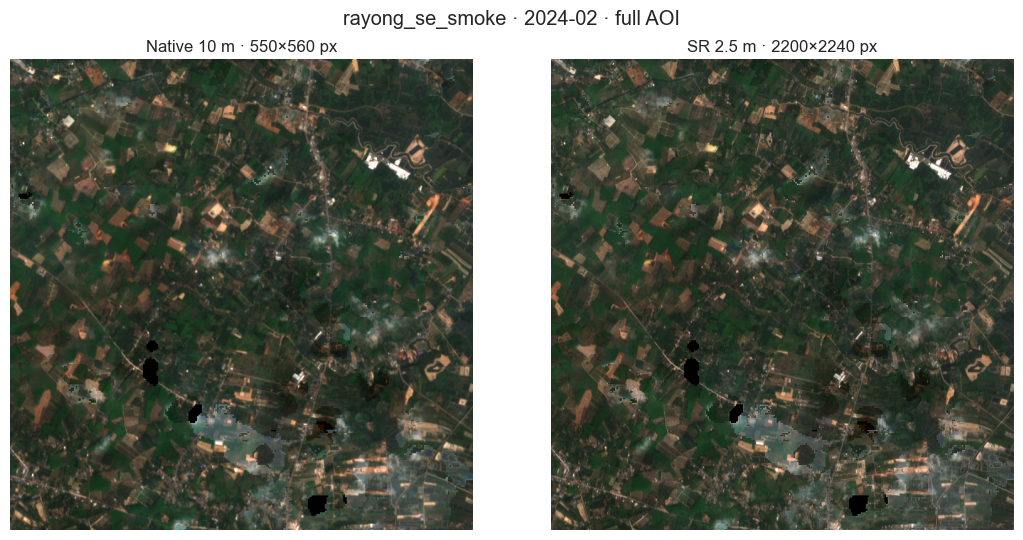

In [9]:
def to_rgb(arr: np.ndarray, gain: float = 3.0) -> np.ndarray:
    """Reflectance (4, H, W) → uint8 RGB (H, W, 3). Band order: B02 B03 B04 B08."""
    rgb = np.clip(arr[[2, 1, 0]] * gain, 0, 1)
    return (rgb.transpose(1, 2, 0) * 255).astype("uint8")


mid = S2.time.values[len(S2.time)//2]
native = S2.sel(time=mid).isel(band_idx=slice(0, 4)).values / 10000.0
sr_now = SR.sel(time=mid).values

fig, ax = plt.subplots(1, 2, figsize=(11, 5.5))
ax[0].imshow(to_rgb(native)); ax[0].set_title(f"Native 10 m · {native.shape[2]}×{native.shape[1]} px"); ax[0].axis("off")
ax[1].imshow(to_rgb(sr_now)); ax[1].set_title(f"SR 2.5 m · {sr_now.shape[2]}×{sr_now.shape[1]} px"); ax[1].axis("off")
plt.suptitle(f"{CFG.aoi_name} · {pd.to_datetime(mid).strftime('%Y-%m')} · full AOI")
plt.tight_layout()
plt.savefig(CFG.out_root / "figs" / "native_vs_sr_full.png", dpi=160, bbox_inches="tight")
plt.show()


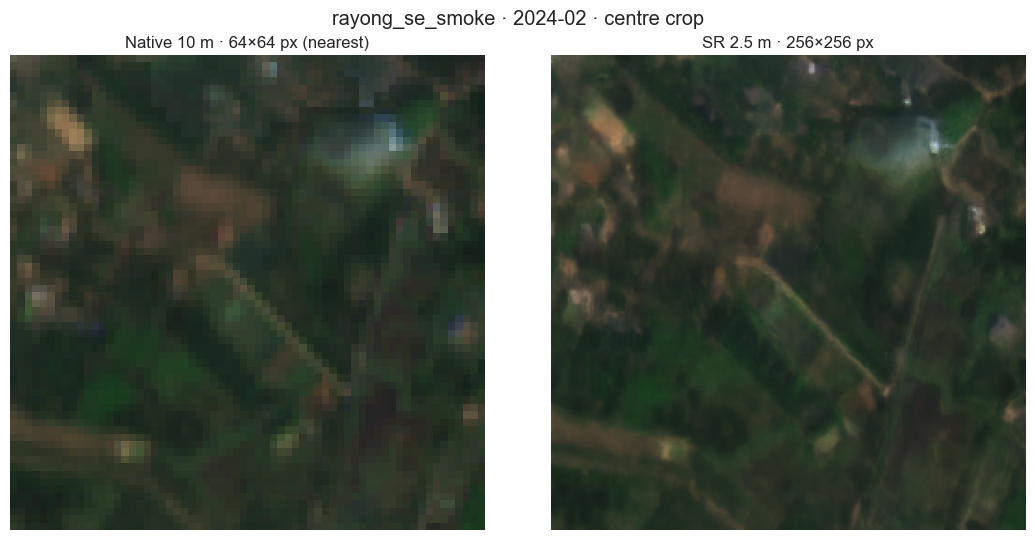

In [10]:
# zoomed crop: take a 64×64 native window (= 256×256 SR), centred on AOI.
H10, W10 = native.shape[1:]
cy, cx = H10 // 2, W10 // 2
win = 32
nat_crop = native[:, cy-win:cy+win, cx-win:cx+win]
sr_crop  = sr_now[:, cy*CFG.sr_scale - win*CFG.sr_scale: cy*CFG.sr_scale + win*CFG.sr_scale,
                     cx*CFG.sr_scale - win*CFG.sr_scale: cx*CFG.sr_scale + win*CFG.sr_scale]

fig, ax = plt.subplots(1, 2, figsize=(11, 5.5))
# nearest-neighbour resize the native crop to match SR pixel count, so the eye
# compares like-for-like instead of being fooled by the smaller native canvas.
ax[0].imshow(to_rgb(nat_crop), interpolation="nearest")
ax[0].set_title(f"Native 10 m · {nat_crop.shape[2]}×{nat_crop.shape[1]} px (nearest)")
ax[0].axis("off")
ax[1].imshow(to_rgb(sr_crop))
ax[1].set_title(f"SR 2.5 m · {sr_crop.shape[2]}×{sr_crop.shape[1]} px")
ax[1].axis("off")
plt.suptitle(f"{CFG.aoi_name} · {pd.to_datetime(mid).strftime('%Y-%m')} · centre crop")
plt.tight_layout()
plt.savefig(CFG.out_root / "figs" / "native_vs_sr_crop.png", dpi=160, bbox_inches="tight")
plt.show()


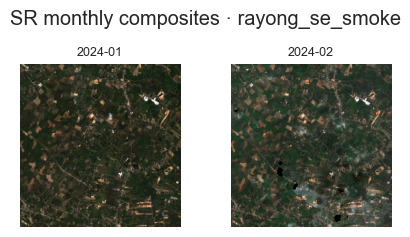

In [11]:
# Monthly SR strip — quick eyeball check that the cloud mask + median worked.
n_t = len(SR.time)
cols = min(n_t, 6)
rows = math.ceil(n_t / cols)
fig, axes = plt.subplots(rows, cols, figsize=(2.2 * cols, 2.4 * rows))
axes = np.atleast_1d(axes).ravel()
for ax in axes: ax.axis("off")
for i, t in enumerate(SR.time.values):
    axes[i].imshow(to_rgb(SR.sel(time=t).values))
    axes[i].set_title(pd.to_datetime(t).strftime("%Y-%m"), fontsize=9)
plt.suptitle(f"SR monthly composites · {CFG.aoi_name}")
plt.tight_layout()
plt.savefig(CFG.out_root / "figs" / "sr_monthly_strip.png", dpi=160, bbox_inches="tight")
plt.show()


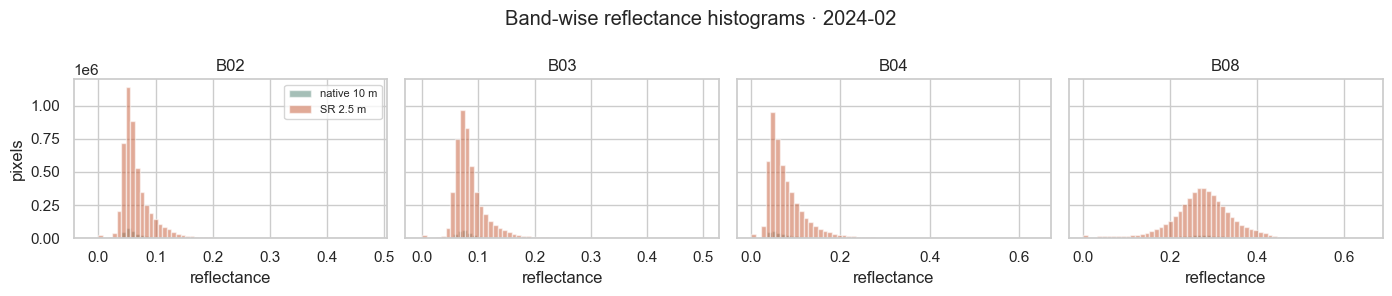

 band    native μ        SR μ    native σ        SR σ
  B02         nan      0.0666         nan      0.0289
  B03         nan      0.0855         nan      0.0317
  B04         nan      0.0782         nan      0.0450
  B08         nan      0.2721         nan      0.0731


In [12]:
# Reflectance histogram per band — sanity check that SR didn't drift the
# distribution. Native + SR should land in the same shape; an extreme tail
# shift means the SR model is leaking into out-of-distribution territory.
fig, axes = plt.subplots(1, 4, figsize=(14, 3), sharey=True)
bands = ["B02", "B03", "B04", "B08"]
for i, ax in enumerate(axes):
    ax.hist(native[i].ravel(),  bins=60, alpha=0.55, label="native 10 m", color="#5B8B7C")
    ax.hist(sr_now[i].ravel(),  bins=60, alpha=0.55, label="SR 2.5 m",    color="#C96442")
    ax.set_title(bands[i]); ax.set_xlabel("reflectance")
axes[0].set_ylabel("pixels"); axes[0].legend(fontsize=8)
plt.suptitle(f"Band-wise reflectance histograms · {pd.to_datetime(mid).strftime('%Y-%m')}")
plt.tight_layout()
plt.savefig(CFG.out_root / "figs" / "sr_band_histograms.png", dpi=160, bbox_inches="tight")
plt.show()

# numeric summary
print(f"{'band':>5}  {'native μ':>10}  {'SR μ':>10}  {'native σ':>10}  {'SR σ':>10}")
for i, b in enumerate(bands):
    print(f"{b:>5}  {native[i].mean():>10.4f}  {sr_now[i].mean():>10.4f}  {native[i].std():>10.4f}  {sr_now[i].std():>10.4f}")


## 5 · Rasterise LDD landuse onto the SR grid

LDD shapefile → label raster co-registered with the SR stack. Sets `LABELS`; downstream code uses it for `extract_class_patches` and `build_pixel_table`.

In [ ]:
from rasterio.features import rasterize

_shp_candidates = list(CFG.ldd_landuse.rglob("*.shp"))
if not _shp_candidates:
    raise FileNotFoundError(
        f"No .shp found under {CFG.ldd_landuse}. "
        f"Drop the LDD landuse shapefile (LU_RYG_*.shp + .shx/.dbf/.prj/.cpg) "
        f"into that folder and re-run. See data/README.md for layout."
    )
LU_SHP = _shp_candidates[0]
if len(_shp_candidates) > 1:
    print(f"note: found {len(_shp_candidates)} shapefiles, using {LU_SHP.name}")
print("LDD landuse:", LU_SHP)

lu = gpd.read_file(LU_SHP).to_crs(SR.rio.crs)
# Map every raw LDD code into the 15-class taxonomy (Others = catch-all).
lu["class_name"] = lu["LU_CODE"].map(lu_code_to_class_name)
lu["lu_int"]     = lu["class_name"].map(class_name_to_int).astype("int32")

print("class counts:")
for name in CLASS_NAMES:
    n = int((lu["class_name"] == name).sum())
    print(f"  {name:<12s} {n:>6d}")

# Back-compat shim: code_to_int now keys on display names so that
# downstream code (§5 extract_class_patches, §6 GenAI runner) can still
# look up class ints by the same dict.
code_to_int = class_name_to_int
int_to_code = int_to_class_name

out_shape = SR.isel(time=0).shape[1:]
LABELS = rasterize(
    [(g, v) for g, v in zip(lu.geometry, lu["lu_int"]) if v > 0],
    out_shape=out_shape, transform=SR.rio.transform(), fill=0, dtype="int32",
)
print(f"labels {LABELS.shape} · non-zero {(LABELS>0).mean():.2%}")


In [ ]:
def extract_class_patches(class_name: str, n: int = 200, size: int = 64) -> np.ndarray:
    """(N, 4, size, size) reflectance patches centred on the class.

    Returns an empty (0, 4, size, size) array when the class has no
    rasterised pixels in this AOI (common in smoke mode) or when every
    candidate hits the raster edge.
    """
    cls = class_name_to_int.get(class_name)
    if cls is None:
        return np.empty((0, 4, size, size), dtype="float32")
    yy, xx = np.where(LABELS == cls)
    if len(yy) == 0:
        return np.empty((0, 4, size, size), dtype="float32")
    n = min(n, len(yy))
    idx = np.random.RandomState(CFG.seed).choice(len(yy), size=n, replace=False)
    H, W = LABELS.shape
    half = size // 2
    sr_mid = SR.isel(time=len(SR.time) // 2).values
    # SR cache files may carry either 0-1 reflectance or 0-10000 integers
    # depending on when they were written. Normalise to 0-1 here.
    scale = 10000.0 if sr_mid.max() > 5 else 1.0
    out = []
    for y, x in zip(yy[idx], xx[idx]):
        if y - half < 0 or x - half < 0 or y + half > H or x + half > W:
            continue
        out.append(sr_mid[:, y - half:y + half, x - half:x + half] / scale)
    if not out:
        return np.empty((0, 4, size, size), dtype="float32")
    return np.stack(out).astype("float32")


patches_by_class: dict[str, np.ndarray] = {}
for c in CFG.minority_classes:
    if c not in class_name_to_int:
        print(f"  {c}: unknown class name (not in TAXONOMY)")
        continue
    patches = extract_class_patches(c)
    if len(patches) == 0:
        print(f"  {c}: 0 patches — no rasterised pixels here, skipping")
        continue
    patches_by_class[c] = patches
    print(f"  {c}: {patches.shape}")

if not patches_by_class:
    print("\nno minority-class patches in this AOI. Pick a bigger AOI "
          "(CFG.smoke_test = False or shift CFG.aoi_bbox), or override "
          "CFG.minority_classes with class names that actually appear.")


## 6 · Generative augmentation — latent-space LoRA

Minority crop classes hold <1 % of pixels. Pure oversampling duplicates noise; we synthesise *new* Sentinel-2 reflectance patches by fine-tuning a small LoRA adapter on the **opensr-ldsrs2** latent diffusion model, per class.

### Architecture

```
              4-band patch x ∈ R^(4×256×256), reflectance in [0, 1]
                        │
                        ▼
              ┌──────────────────────┐
              │   VAE encoder Eφ     │   (frozen, CompVis-style)
              └──────────────────────┘
                        │  z₀ ∈ R^(4×h×w),  scale s ≈ 0.18215
        ┌───────────────┴────────────────┐
        │                                │
        ▼                                ▼
   LR latent z_c                    DDPM forward q(z_t | z₀)
   (encode of LR↑256)               z_t = √ᾱ_t z₀ + √(1-ᾱ_t) ε
        │                                │
        └────────────┬───────────────────┘
                     ▼
              concat → 8-channel input
                     │
                     ▼
       ┌─────────────────────────────┐
       │  UNet_θ  (CompVis vanilla   │  ← LoRA adapters on
       │  attention, Conv2d 1×1 qkv) │     q / k / v / proj_out
       └─────────────────────────────┘
                     │
                     ▼            predicted noise ε̂
              ─── DDIM denoise ──── (T steps)
                     │
                     ▼
              ┌──────────────────────┐
              │   VAE decoder Dφ     │
              └──────────────────────┘
                     │
                     ▼
        synthetic 4-band patch x̂ ∈ R^(4×256×256)
```

### Loss

Standard ε-prediction DDPM loss in **latent space**, with the LR latent as concatenation conditioning:

$$
\mathcal{L}_{\text{LoRA}}(\theta)
= \mathbb{E}_{x,\,\varepsilon,\,t}\Bigl[\;
    \bigl\lVert \varepsilon - \varepsilon_\theta\bigl(\,[z_t \parallel z_c],\, t\bigr) \bigr\rVert_2^2
  \;\Bigr]
$$

where

$$
\begin{aligned}
z_0     &= s \cdot E_\varphi(x).\text{sample}() & x \sim \text{real minority patches}\\
z_c     &= s \cdot E_\varphi(\text{LR}\!\uparrow).\text{sample}() & \text{LR}\!\uparrow = \text{bilinear-up}(\text{avg-pool}_4(x)) \\
z_t     &= \sqrt{\bar\alpha_t}\, z_0 + \sqrt{1 - \bar\alpha_t}\, \varepsilon &
\varepsilon \sim \mathcal{N}(0, I),\ t \sim \mathcal{U}\{1,\dots,T\}
\end{aligned}
$$

LoRA reparameterises every target weight matrix as $W' = W + \frac{\alpha}{r} BA$ with $A \in \mathbb{R}^{r \times d_\text{in}}$, $B \in \mathbb{R}^{d_\text{out} \times r}$, $r = 8$, $\alpha = 16$. Only $A$ and $B$ receive gradients — the rest of the UNet + VAE stay frozen (≈10 MB trainable per class vs ≈110 MB total).

### Sampling

After training, sampling is the same `model.forward(LR_seed, sampling_steps=T)` call already used elsewhere — the LoRA-wrapped UNet replaces the original in-place, so class-conditioning is baked into the weights.

LR seeds are real minority patches with light Gaussian noise injected in pixel space (so each sample drifts to a new place in the manifold). Outputs land in `cache/synth/<class>/patch_NNN.npy` + `.png`.

In [ ]:
# Latent-space LoRA generative augmentation for opensr-ldsrs2.
import torch.nn as nn
import torch.nn.functional as F
from peft import LoraConfig, get_peft_model

# ── knobs ────────────────────────────────────────────────────────────
USE_GENAI         = True
USE_LORA          = True
LORA_RANK         = 8
LORA_ALPHA        = 16
LORA_EPOCHS       = 3 if CFG.smoke_test else 20
LORA_LR           = 1e-4
LORA_BATCH        = 2 if CFG.smoke_test else 4
LORA_TARGET_PX    = 256                                  # SR-side patch size used for training
N_SYNTH_PER_CLASS = 40 if CFG.smoke_test else 200
SAMPLE_NOISE      = 0.03                                 # LR-side jitter at sample time
VIZ_PER_CLASS     = 4
SYNTH_OUT_ROOT    = CFG.cache_root / "synth"
LORA_OUT_ROOT     = CFG.cache_root / "lora"
for _d in (SYNTH_OUT_ROOT, LORA_OUT_ROOT):
    _d.mkdir(parents=True, exist_ok=True)


# ── helpers ──────────────────────────────────────────────────────────
def _find_unet(model):
    """opensr-ldsrs2 keeps the UNet at model.model.diffusion_model. Older
    forks expose it at .unet — try both."""
    for path in ("model.diffusion_model", "model.unet", "unet"):
        obj = model
        try:
            for part in path.split("."):
                obj = getattr(obj, part)
            return obj, path
        except AttributeError:
            continue
    raise AttributeError("UNet not found inside SRLatentDiffusion")


def _pick_lora_targets(unet) -> list[str]:
    """CompVis vanilla AttnBlock uses Conv2d 1x1 q / k / v / proj_out."""
    leaves = {"q", "k", "v", "proj_out",
              "to_q", "to_k", "to_v", "to_out.0", "to_out",
              "q_proj", "k_proj", "v_proj", "out_proj"}
    found = set()
    for name, mod in unet.named_modules():
        if not isinstance(mod, (nn.Linear, nn.Conv1d, nn.Conv2d)):
            continue
        leaf = name.rsplit(".", 1)[-1]
        parent = name.rsplit(".", 1)[0].lower() if "." in name else ""
        if leaf in leaves and ("attn" in parent or "attention" in parent or "self_attn" in parent):
            found.add(leaf)
    return sorted(found)


def _encode_z(model, x: torch.Tensor) -> torch.Tensor:
    """4-band reflectance -> latent. CompVis API: encode_first_stage()."""
    enc = model.encode_first_stage(x)
    z = enc.sample() if hasattr(enc, "sample") else enc
    return z * float(getattr(model, "scale_factor", 1.0))


def _q_sample(model, z0: torch.Tensor, eps: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
    """z_t = sqrt(alpha_cum_t) z0 + sqrt(1 - alpha_cum_t) eps."""
    ac = model.alphas_cumprod.to(z0.device)[t].view(-1, 1, 1, 1)
    return ac.sqrt() * z0 + (1 - ac).sqrt() * eps


# ── per-class LoRA training ──────────────────────────────────────────
def train_lora_class(class_name: str, real_patches: np.ndarray, epochs: int = LORA_EPOCHS, lr: float = LORA_LR):
    """real_patches: (N, 4, 64, 64) reflectance in [0, 1]. We bilinearly
    upsample to LORA_TARGET_PX so the VAE sees the resolution it was
    trained on, then run the latent-space DDPM loss with the LR latent
    concatenated as conditioning (mirrors the model's SR forward pass)."""
    base = get_sr_model()
    unet, unet_path = _find_unet(base)
    targets = _pick_lora_targets(unet)
    if not targets:
        raise RuntimeError(f"no LoRA targets in {unet_path} — inspect named_modules()")
    print(f"[{class_name}] LoRA targets ({len(targets)}): {targets}")

    cfg = LoraConfig(r=LORA_RANK, lora_alpha=LORA_ALPHA,
                     target_modules=targets, lora_dropout=0.0, bias="none")
    unet_lora = get_peft_model(unet, cfg)
    trainable = sum(p.numel() for p in unet_lora.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in unet_lora.parameters())
    print(f"[{class_name}] trainable {trainable:,} / {total:,} params ({100 * trainable / total:.2f}%)")

    # Re-attach into the model graph so model.forward() uses adapted weights.
    parent = base
    parts = unet_path.split(".")
    for p in parts[:-1]:
        parent = getattr(parent, p)
    setattr(parent, parts[-1], unet_lora)

    opt = torch.optim.AdamW([p for p in unet_lora.parameters() if p.requires_grad], lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(torch.from_numpy(real_patches).float()),
        batch_size=LORA_BATCH, shuffle=True, drop_last=True,
    )
    T = int(getattr(base, "num_timesteps", 1000))

    for ep in range(epochs):
        running = 0.0
        steps = 0
        for (x,) in loader:
            x = x.to(DEVICE)
            x = F.interpolate(x, size=(LORA_TARGET_PX, LORA_TARGET_PX), mode="bilinear", align_corners=False)
            lr_up = F.interpolate(F.avg_pool2d(x, 4), size=x.shape[-2:], mode="bilinear", align_corners=False)
            with torch.no_grad():
                z0     = _encode_z(base, x)
                z_cond = _encode_z(base, lr_up)
            t   = torch.randint(0, T, (x.size(0),), device=DEVICE)
            eps = torch.randn_like(z0)
            zt  = _q_sample(base, z0, eps, t)
            unet_in = torch.cat([zt, z_cond], dim=1)
            pred = unet_lora(unet_in, t)
            pred_eps = pred.sample if hasattr(pred, "sample") else pred
            loss = F.mse_loss(pred_eps, eps)
            opt.zero_grad(); loss.backward(); opt.step()
            running += loss.item(); steps += 1
        sched.step()
        if ep % max(1, epochs // 5) == 0 or ep == epochs - 1:
            print(f"  [{class_name}] ep {ep:3d}/{epochs}  loss {running / max(steps, 1):.4f}")

    out = LORA_OUT_ROOT / f"{class_name.replace(' ', '_').lower()}.pt"
    lora_state = {k: v.detach().cpu()
                  for k, v in unet_lora.state_dict().items()
                  if "lora" in k.lower()}
    torch.save(lora_state, out)
    print(f"[{class_name}] saved LoRA -> {out}")
    return base


# ── feature row + save helpers (unchanged contract) ─────────────────
def _features_from_patch(patch: np.ndarray) -> dict:
    eps = 1e-6
    B02, B03, B04, B08 = patch[0], patch[1], patch[2], patch[3]
    ndvi = (B08 - B04) / (B08 + B04 + eps)
    ndwi = (B03 - B08) / (B03 + B08 + eps)
    f: dict = {}
    for name, b in zip(["B02", "B03", "B04", "B08"], [B02, B03, B04, B08]):
        f[f"{name}_mean"] = float(b.mean())
        f[f"{name}_std"]  = float(b.std())
        f[f"{name}_p90"]  = float(np.percentile(b, 90))
        f[f"{name}_min"]  = float(b.min())
        f[f"{name}_max"]  = float(b.max())
    f["NDVI_mean"] = float(ndvi.mean())
    f["NDVI_max"]  = float(ndvi.max())
    f["NDVI_amp"]  = float(ndvi.max() - ndvi.min())
    f["NDWI_mean"] = float(ndwi.mean())
    return f


@torch.no_grad()
def _sample_synth_patch(model, seed_patch: np.ndarray, noise: float = SAMPLE_NOISE) -> np.ndarray:
    """LoRA-adapted SR forward pass with a noised real LR seed."""
    lr = torch.from_numpy(seed_patch).float().to(DEVICE).unsqueeze(0)
    if noise > 0:
        lr = (lr + noise * torch.randn_like(lr)).clamp(0.0, 1.0)
    out = model.forward(lr, sampling_steps=CFG.sr_steps)
    arr = out.squeeze(0).cpu().numpy()
    return np.clip(arr, 0.0, 1.0).astype("float32")


def _save_synth_patch(class_name: str, idx: int, patch: np.ndarray) -> None:
    safe = class_name.replace(" ", "_").lower()
    out_dir = SYNTH_OUT_ROOT / safe
    out_dir.mkdir(parents=True, exist_ok=True)
    np.save(out_dir / f"patch_{idx:03d}.npy", patch)
    rgb = np.stack([patch[2], patch[1], patch[0]], axis=-1)
    rgb = np.clip(rgb / max(1e-6, np.percentile(rgb, 99)), 0.0, 1.0)
    rgb_u8 = (rgb * 255).astype(np.uint8)
    try:
        from PIL import Image
        Image.fromarray(rgb_u8).save(out_dir / f"patch_{idx:03d}.png")
    except Exception:
        plt.imsave(out_dir / f"patch_{idx:03d}.png", rgb_u8)


# ── run: train LoRA + sample per minority class ─────────────────────
synth_rows: list[dict] = []
viz_cache: dict[str, list[np.ndarray]] = {}

if USE_GENAI:
    for cls in CFG.minority_classes:
        if cls not in patches_by_class:
            print(f"  skip {cls} - no real patches available")
            continue
        real = patches_by_class[cls]
        if USE_LORA:
            try:
                model = train_lora_class(cls, real)
            except Exception as e:
                print(f"[{cls}] LoRA training failed: {e}")
                print(f"[{cls}] falling back to base SR model")
                model = get_sr_model()
        else:
            model = get_sr_model()

        print(f"[{cls}] sampling {N_SYNTH_PER_CLASS} synthetic patches")
        viz_cache[cls] = []
        for i in tqdm(range(N_SYNTH_PER_CLASS), desc=cls, leave=False):
            seed = real[i % len(real)]
            patch = _sample_synth_patch(model, seed)
            row = _features_from_patch(patch)
            row["y"] = -1
            row["x"] = -1
            row["label"] = class_name_to_int[cls]
            row["_synth"] = True
            row["_lora"]  = USE_LORA
            synth_rows.append(row)
            if i < VIZ_PER_CLASS:
                viz_cache[cls].append(patch)
                _save_synth_patch(cls, i, patch)

print(f"generated {len(synth_rows)} synthetic rows for {list(viz_cache)}")
print(f"raster patches under {SYNTH_OUT_ROOT}")


### 6.1 · Inspect synthetic multispectral patches

Render RGB / false-colour NIR / NDVI side-by-side for each minority class so the team can confirm the generative output reads as Sentinel-2 imagery.

In [ ]:
# Pull from viz_cache (set above) or from disk so this cell runs standalone
# after a kernel restart.
def _stretch(img: np.ndarray, p: float = 99.0) -> np.ndarray:
    hi = max(1e-6, np.percentile(img, p))
    return np.clip(img / hi, 0.0, 1.0)


def _safe(name: str) -> str:
    return name.replace(" ", "_").lower()


def _load_synth_from_disk(cls: str, k: int) -> list[np.ndarray]:
    out_dir = SYNTH_OUT_ROOT / _safe(cls)
    if not out_dir.exists():
        return []
    return [np.load(p) for p in sorted(out_dir.glob("patch_*.npy"))[:k]]


def _show_grid(cls: str, patches: list[np.ndarray]) -> None:
    if not patches:
        print(f"[{cls}] no patches")
        return
    n = len(patches)
    fig, axes = plt.subplots(n, 3, figsize=(8.5, 2.7 * n), squeeze=False)
    fig.suptitle(f"Synthetic S2 patches · class {cls}", y=1.0, fontsize=11, fontweight="bold")
    eps = 1e-6
    for r, patch in enumerate(patches):
        B02, B03, B04, B08 = patch
        rgb  = _stretch(np.stack([B04, B03, B02], axis=-1))
        nir  = _stretch(np.stack([B08, B04, B03], axis=-1))
        ndvi = (B08 - B04) / (B08 + B04 + eps)
        axes[r, 0].imshow(rgb);  axes[r, 0].set_title("RGB" if r == 0 else "", fontsize=9)
        axes[r, 1].imshow(nir);  axes[r, 1].set_title("false-NIR" if r == 0 else "", fontsize=9)
        im = axes[r, 2].imshow(ndvi, vmin=-0.2, vmax=0.9, cmap="RdYlGn")
        axes[r, 2].set_title("NDVI" if r == 0 else "", fontsize=9)
        plt.colorbar(im, ax=axes[r, 2], fraction=0.046, pad=0.04)
        for a in axes[r]:
            a.set_xticks([]); a.set_yticks([])
    plt.tight_layout()
    plt.show()
    print(f"[{cls}] {n} patches · {SYNTH_OUT_ROOT / _safe(cls)}")


classes = list(viz_cache) if viz_cache else [c for c in CFG.minority_classes if (SYNTH_OUT_ROOT / _safe(c)).exists()]
if not classes:
    print("Run §6 with USE_GENAI=True first, then re-execute this cell.")
else:
    for cls in classes:
        _show_grid(cls, viz_cache.get(cls) or _load_synth_from_disk(cls, VIZ_PER_CLASS))


## 7 · Pixel feature table

Monthly band stats + NDVI/NDWI per stride-sampled AOI pixel. Synthetic rows from §6 are concatenated here, so the classifier sees real + synthetic in a single frame.

In [17]:
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern


def build_pixel_table(stride: int = 8) -> pd.DataFrame:
    n_t = len(SR.time)
    H, W = LABELS.shape
    yy, xx = np.meshgrid(np.arange(0, H, stride), np.arange(0, W, stride), indexing="ij")
    yy, xx = yy.ravel(), xx.ravel()
    keep = LABELS[yy, xx] > 0
    yy, xx = yy[keep], xx[keep]
    print(f"sampled {len(yy):,} pixels (stride={stride})")

    spec = np.zeros((len(yy), n_t, 4), dtype="float32")
    for ti, t in enumerate(SR.time.values):
        spec[:, ti, :] = SR.sel(time=t).values[:, yy, xx].T / 10000.0

    stats: dict = {}
    for b, name in enumerate(["B02", "B03", "B04", "B08"]):
        stats[f"{name}_mean"] = spec[:, :, b].mean(axis=1)
        stats[f"{name}_std"]  = spec[:, :, b].std(axis=1)
        stats[f"{name}_p90"]  = np.percentile(spec[:, :, b], 90, axis=1)
        stats[f"{name}_min"]  = spec[:, :, b].min(axis=1)
        stats[f"{name}_max"]  = spec[:, :, b].max(axis=1)
    ndvi = (spec[:, :, 3] - spec[:, :, 2]) / (spec[:, :, 3] + spec[:, :, 2] + 1e-6)
    ndwi = (spec[:, :, 1] - spec[:, :, 3]) / (spec[:, :, 1] + spec[:, :, 3] + 1e-6)
    stats["NDVI_mean"] = ndvi.mean(axis=1)
    stats["NDVI_max"]  = ndvi.max(axis=1)
    stats["NDVI_amp"]  = ndvi.max(axis=1) - ndvi.min(axis=1)
    stats["NDWI_mean"] = ndwi.mean(axis=1)

    df = pd.DataFrame(stats)
    df["y"], df["x"], df["label"] = yy, xx, LABELS[yy, xx]
    df["_synth"] = False
    return df


def _save_df(df: pd.DataFrame, base: Path) -> Path:
    # Parquet when the engine is importable in this kernel, pickle otherwise.
    try:
        path = base.with_suffix(".parquet")
        df.to_parquet(path)
        return path
    except Exception as e:
        path = base.with_suffix(".pkl")
        df.to_pickle(path)
        print(f"  parquet unavailable ({type(e).__name__}); wrote pickle: {path.name}")
        print( "  install pyarrow into THIS kernel + restart:  %pip install pyarrow")
        return path


DF = build_pixel_table(stride=8)
# Splice in the synth rows produced by §6.
if synth_rows:
    DF = pd.concat([DF, pd.DataFrame(synth_rows)], ignore_index=True)
    print(f"appended {int(DF['_synth'].sum())} synthetic rows from §6")

OUT_TABLE = _save_df(DF, CFG.out_root / "pixel_table")
print(DF.shape, "->", OUT_TABLE)
DF.head()


sampled 77,000 pixels (stride=8)
appended 80 synthetic rows from §6
(77080, 28) -> D:\Github\rayong-tracker\data\_out\pixel_table.parquet


,B02_mean,B02_std,B02_p90,B02_min,B02_max,B03_mean,B03_std,B03_p90,B03_min,B03_max,...,B08_min,B08_max,NDVI_mean,NDVI_max,NDVI_amp,NDWI_mean,y,x,label,_synth
0,0.000019,1.468834e-08,0.000019,0.000019,0.000019,0.000022,6.143746e-07,0.000022,0.000021,0.000022,...,0.000031,0.000034,0.220076,0.247751,0.055351,-0.194128,0,0,208,False
1,0.000013,9.889063e-07,0.000014,0.000012,0.000014,0.000014,7.696876e-07,0.000014,0.000013,0.000014,...,0.000014,0.000016,0.065773,0.091630,0.051715,-0.046385,0,8,208,False
2,0.000013,1.283438e-06,0.000014,0.000012,0.000015,0.000014,1.298750e-06,0.000015,0.000012,0.000015,...,0.000019,0.000021,0.196738,0.205063,0.016651,-0.185988,0,16,208,False
3,0.000009,7.980334e-07,0.000009,0.000008,0.000009,0.000010,1.307224e-06,0.000011,0.000009,0.000012,...,0.000018,0.000020,0.290866,0.369326,0.156921,-0.283650,0,24,208,False
4,0.000005,2.073327e-07,0.000005,0.000005,0.000005,0.000006,1.479066e-09,0.000006,0.000006,0.000006,...,0.000015,0.000020,0.540756,0.557286,0.033060,-0.463955,0,32,208,False


## 8 · Random Forest cascade

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Synth rows + class_weight="balanced_subsample" handle imbalance, so no
# upstream oversampler is needed.
X_cols = [c for c in DF.columns if c not in ("y", "x", "label", "_synth")]
X, y = DF[X_cols].values, DF["label"].values

uniq, counts = np.unique(y, return_counts=True)
print("class counts:")
for k, n in zip(uniq, counts):
    print(f"  {int(k):2d} {int_to_class_name.get(int(k), '?'):<12s} {int(n):>6d}")

X_tr, X_va, y_tr, y_va = train_test_split(X, y, test_size=0.2, stratify=y, random_state=CFG.seed)

rf = RandomForestClassifier(
    n_estimators=CFG.rf_n_estimators, max_depth=CFG.rf_max_depth,
    n_jobs=-1, random_state=CFG.seed, class_weight="balanced_subsample",
)
rf.fit(X_tr, y_tr)
y_pred = rf.predict(X_va)

# classification_report wants target_names aligned with sorted unique labels.
labels_sorted = sorted(set(rf.classes_.tolist()))
target_names = [int_to_class_name.get(int(i), str(i)) for i in labels_sorted]
print(classification_report(y_va, y_pred, labels=labels_sorted, target_names=target_names, digits=3))


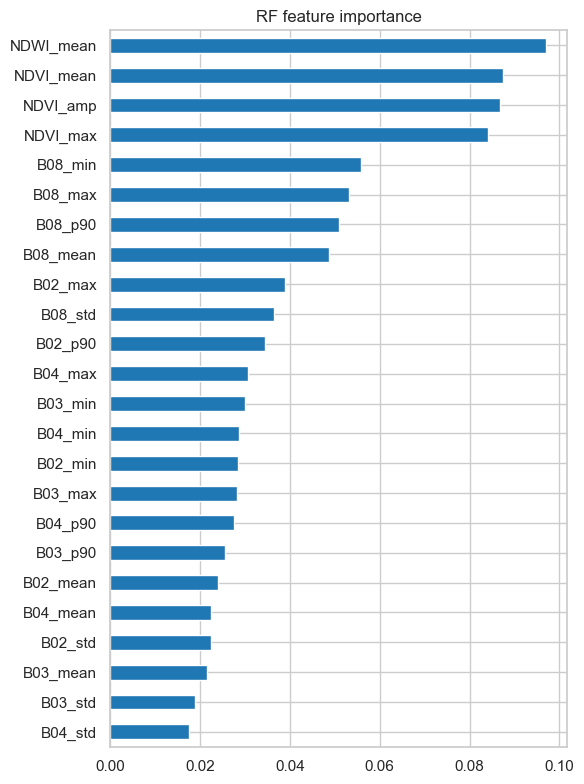

In [19]:
imp = pd.Series(rf.feature_importances_, index=X_cols).sort_values(ascending=True)
plt.figure(figsize=(6, 8)); imp.plot(kind="barh")
plt.title("RF feature importance"); plt.tight_layout()
plt.savefig(CFG.out_root / "figs" / "rf_importance.png", dpi=160, bbox_inches="tight")
plt.show()


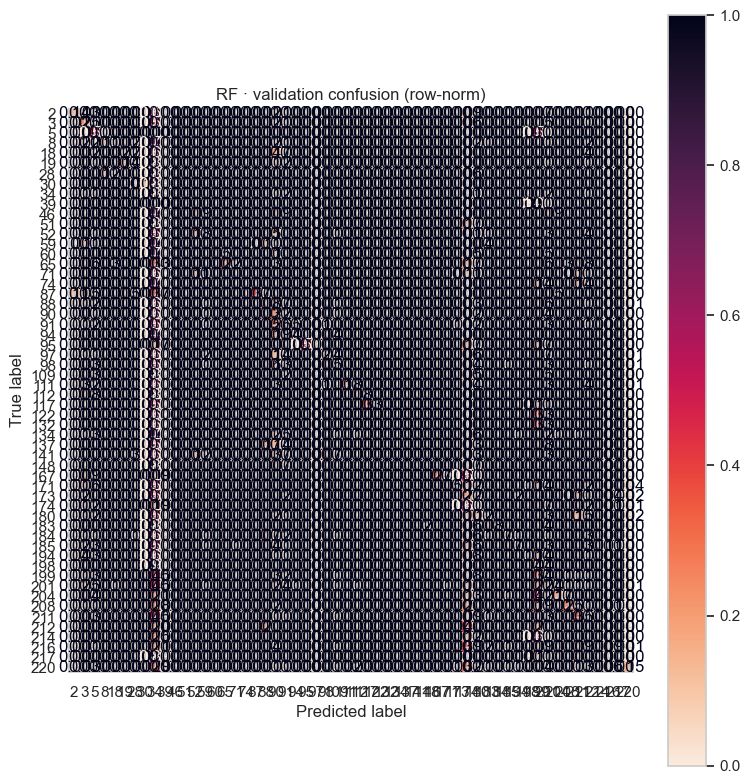

In [20]:
fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay.from_predictions(y_va, y_pred, normalize="true", cmap="rocket_r", values_format=".2f", ax=ax)
ax.set_title("RF · validation confusion (row-norm)")
plt.tight_layout()
plt.savefig(CFG.out_root / "figs" / "rf_confusion.png", dpi=160, bbox_inches="tight")
plt.show()


### 8.1 · Cascade — second RF on minority classes

In [ ]:
# Stage-2 RF targets minority classes only. A sample is routed to stage-2
# when stage-1 confidence < conf_thresh OR predicts a non-minority class.
minor_ints = [class_name_to_int[c] for c in CFG.minority_classes if c in class_name_to_int]
mask = np.isin(y, minor_ints)
print("minority pixels:", mask.sum())

rf_minor = RandomForestClassifier(
    n_estimators=400, n_jobs=-1, random_state=CFG.seed,
    class_weight="balanced_subsample",
)
if mask.sum() > 100:
    rf_minor.fit(X[mask], y[mask])


def cascade_predict(X_in, conf_thresh: float = 0.6):
    proba = rf.predict_proba(X_in)
    pred = rf.classes_[proba.argmax(axis=1)]
    conf = proba.max(axis=1)
    route = (conf < conf_thresh) | np.isin(pred, [c for c in rf.classes_ if c not in minor_ints])
    if mask.sum() > 100 and route.any():
        pred[route] = rf_minor.predict(X_in[route])
    return pred


y_pred_cas = cascade_predict(X_va)
labels_sorted = sorted(set(rf.classes_.tolist()))
target_names = [int_to_class_name.get(int(i), str(i)) for i in labels_sorted]
print("cascade:")
print(classification_report(y_va, y_pred_cas, labels=labels_sorted, target_names=target_names, digits=3))


In [22]:
import joblib
joblib.dump(rf,       CFG.out_root / "rf_stage1.joblib")
joblib.dump(rf_minor, CFG.out_root / "rf_stage2_minor.joblib")
(CFG.out_root / "code_to_int.json").write_text(json.dumps({k: int(v) for k, v in code_to_int.items()}, ensure_ascii=False, indent=2), encoding="utf-8")
print("saved →", CFG.out_root)


saved → D:\Github\rayong-tracker\data\_out


## 9 · Board feedback

Map outputs back to (member, stage) `done / total` rows in Supabase:

| Stage  | `done`                                                  | `total`                     |
| ------ | ------------------------------------------------------- | --------------------------- |
| Data   | cloud-free monthly composites fetched                   | months requested (≤12)      |
| SR     | SR GeoTIFFs persisted in `_cache/s2_sr/`                | same as Data                |
| GenAI  | LoRA adapters trained                                   | `len(CFG.minority_classes)` |
| Feat   | rows in `pixel_table.parquet` (`÷1000`)                 | target row budget           |
| RF     | `1` per model dumped (stage-1 + cascade)                | `2`                         |

Edit numbers in the tracker UI, or POST to the Supabase REST endpoint.


## 10 · Export `public/class-stats.json`

Standalone alternative: `python notebooks/export_class_stats.py` (no need to run the heavy cells above).


In [ ]:
import json, math
from datetime import datetime, timezone

RAYONG_CENTER = {"lng": 101.4291, "lat": 12.8539}

try:
    import mgrs as _mgrs_mod
    _mgrs = _mgrs_mod.MGRS()
except Exception:
    _mgrs = None
    print("note: pip install mgrs to add the per-S2-tile breakdown")

lu_m  = lu.to_crs(32647).copy()
lu_ll = lu.to_crs(4326).copy()
lu_ll["area_km2"] = (lu_m.area / 1e6).values
_cen = lu_m.geometry.centroid.to_crs(4326)
lu_ll["_cen_lng"], lu_ll["_cen_lat"] = _cen.x.values, _cen.y.values


def _quad(lng, lat):
    return ("N" if lat >= RAYONG_CENTER["lat"] else "S") + ("E" if lng >= RAYONG_CENTER["lng"] else "W")


def _tile(lng, lat):
    if _mgrs is None: return None
    try:
        s = _mgrs.toMGRS(lat, lng, MGRSPrecision=0)
        return s[:5] if isinstance(s, str) and len(s) >= 5 else None
    except Exception: return None


lu_ll["_quadrant"] = [_quad(x, y) for x, y in zip(lu_ll._cen_lng, lu_ll._cen_lat)]
lu_ll["_s2_tile"]  = [_tile(x, y) for x, y in zip(lu_ll._cen_lng, lu_ll._cen_lat)]

# Collapse raw LU codes into the 15-class taxonomy. The webapp's Class
# Distribution panel then shows the same labels the team sees in the
# pipeline guide ("Rice", "Durian", ...), not raw LDD codes.
CLASS_COL = "LUL2_CODE" if "LUL2_CODE" in lu_ll.columns else "LU_CODE"
lu_ll[CLASS_COL] = lu_ll[CLASS_COL].astype(str).fillna("")
lu_ll = lu_ll[~lu_ll[CLASS_COL].str.contains("/")].copy()  # drop mixed-class polygons
lu_ll["_class"] = lu_ll[CLASS_COL].map(lu_code_to_class_name)

# Preserve a fixed order matching CLASS_NAMES so colours stay stable across runs.
total_by_class = lu_ll.groupby("_class")["area_km2"].sum()
ordered = [c for c in CLASS_NAMES if total_by_class.get(c, 0.0) > 0]
# Append any unexpected buckets (shouldn't happen — TAXONOMY catches all via "Others").
for c in total_by_class.index:
    if c not in ordered:
        ordered.append(c)

minority_ids = list(CFG.minority_classes)

PALETTE = ["#3F7D58","#3F6E97","#C96442","#B68A2E","#7B5BA6","#9B5C7A",
           "#4F7A95","#7C7A52","#A85C9D","#5F8A6E","#8B6F47","#D4A748",
           "#5B8B7C","#A67B5B","#6B7280","#9B7CB6","#C68A6C","#7AA66D"]
MINORITY_COLOR = "#B14B3D"

class_defs = []
for i, cid in enumerate(ordered):
    is_min = cid in minority_ids
    class_defs.append({
        "id": cid,
        "label": cid,
        "color": MINORITY_COLOR if is_min else PALETTE[i % len(PALETTE)],
        "minority": is_min,
    })


def _block(df):
    grp = df.groupby("_class")["area_km2"].sum().reindex(ordered, fill_value=0.0)
    total = float(grp.sum())
    rows = [{"id": cid, "area_km2": float(grp.loc[cid]), "share": float(grp.loc[cid] / total) if total else 0.0} for cid in ordered]
    rows.sort(key=lambda c: -c["share"])
    return {"area_km2_total": total, "classes": rows}


def _metrics(block):
    sh = [c["share"] for c in block["classes"] if c["share"] > 0]
    shannon = -sum(s * math.log2(s) for s in sh)
    xs = sorted(sh); n = len(xs)
    gini = (2 * sum((i+1) * s for i, s in enumerate(xs)) / (n * sum(xs))) - (n + 1) / n if xs else 0.0
    return {"shannon": round(shannon, 4), "gini": round(gini, 4),
            "max_min_ratio": round(max(xs)/min(xs), 3) if xs else 0.0}


areas = [{"key": "overall", "label": "All Rayong", "kind": "overall", **_block(lu_ll), "metrics": _metrics(_block(lu_ll))}]
for q, lbl in [("NW","Northwest"),("NE","Northeast"),("SW","Southwest"),("SE","Southeast")]:
    b = _block(lu_ll[lu_ll["_quadrant"] == q])
    areas.append({"key": q, "label": lbl, "kind": "quadrant", **b, "metrics": _metrics(b)})

if _mgrs is not None:
    for tile, sub in sorted(lu_ll.groupby("_s2_tile")):
        if not tile: continue
        b = _block(sub)
        if b["area_km2_total"] < 1.0: continue
        areas.append({"key": str(tile), "label": str(tile), "kind": "s2_tile", **b, "metrics": _metrics(b)})

payload = {
    "version": 1,
    "generated_at": datetime.now(timezone.utc).isoformat().replace("+00:00", "Z"),
    "source": f"LDD landuse · {LU_SHP.name}",
    "taxonomy": list(CLASS_NAMES),
    "classes": class_defs,
    "areas": areas,
}

for root in (CFG.repo_root, Path.cwd().parent, Path.cwd()):
    if (root / "package.json").exists():
        out_path = root / "public" / "class-stats.json"
        break
else:
    out_path = CFG.repo_root / "public" / "class-stats.json"
out_path.parent.mkdir(parents=True, exist_ok=True)
out_path.write_text(json.dumps(payload, ensure_ascii=False, indent=2), encoding="utf-8")
print(f"wrote {out_path} · {len(class_defs)} classes · {len(areas)} areas")
